# Credit Card Fraud Detection

## Extreme Class Imbalance, Oversampling, and Threshold Tuning

This notebook presents a reproducible fraud-detection workflow based on the European cardholders dataset. The focus is deliberately placed on **fraud recall**, **precision-recall trade-offs**, and **operational threshold selection**, rather than on raw accuracy alone.

### Executive Summary

- The dataset is extremely imbalanced: only 492 frauds out of 284,807 transactions.
- A naive majority baseline reaches very high accuracy but detects no fraud at all.
- The final selected model is a **SMOTE-based logistic regression with tuned thresholding**.
- On the held-out test split, the tuned version reaches a much more professional balance between recall and false positives.


## Project Scope

The structure of this project is the following:

1. quick audit of the dataset and class imbalance,
2. validation benchmark across several model families,
3. threshold tuning for the best high-recall candidate,
4. interpretation of the final test-set results,
5. reproducibility through a benchmark script and saved artifacts.

Note : The heavy computation is handled in model_benchmark.py. 

The benchmark uses a roughly `70/15/15` train/validation/test split.


In [1]:
from pathlib import Path
import json

import pandas as pd
from IPython.display import display, Image

PROJECT_DIR = Path.cwd()
DATA_PATH = PROJECT_DIR / 'data' / 'creditcard.csv'
ARTIFACT_DIR = PROJECT_DIR / 'artifacts'

summary = json.loads((ARTIFACT_DIR / 'summary.json').read_text())
validation_metrics = pd.read_csv(ARTIFACT_DIR / 'validation_metrics.csv')
test_metrics = pd.read_csv(ARTIFACT_DIR / 'test_metrics.csv')

if DATA_PATH.exists():
    df = pd.read_csv(DATA_PATH)
else:
    df = None

overview = pd.DataFrame([
    {
        'Dataset rows': summary['dataset_rows'],
        'Fraud cases': summary['fraud_cases'],
        'Fraud rate (%)': summary['fraud_rate_pct'],
        'Train rows': summary['train_rows'],
        'Validation rows': summary['valid_rows'],
        'Test rows': summary['test_rows'],
        'Selected validation model': summary['best_model_validation'],
    }
])

display(overview)


,Dataset rows,Fraud cases,Fraud rate (%),Train rows,Validation rows,Test rows,Selected validation model
0,284807,492,0.1727,199364,42721,42722,smote_logistic


## Data Snapshot

The dataset contains `284,807` transactions and `492` confirmed fraud cases, which corresponds to a fraud rate of roughly `0.17%`. This explains why a majority-class baseline can appear accurate while completely failing on the minority class.

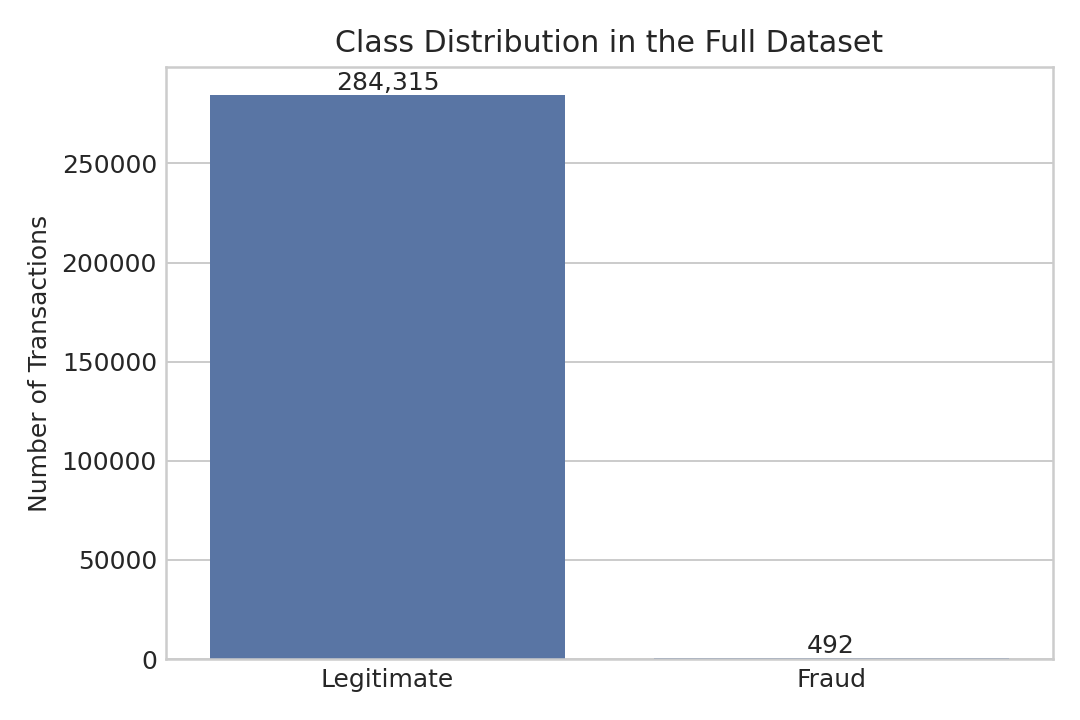

In [2]:
Image(filename=str(ARTIFACT_DIR / "class_distribution.png"))

## Validation Benchmark

The benchmark compares several families of models:

- a majority-class dummy baseline,
- standard logistic regression,
- cost-sensitive logistic regression,
- SMOTE logistic regression,
- Borderline-SMOTE logistic regression,
- a balanced random forest,
- histogram-based gradient boosting.

The validation ranking below should be read with the fraud objective in mind. Accuracy is reported for completeness, but the most relevant metrics are recall, precision, PR AUC, and specificity.

In [3]:
validation_view = validation_metrics[[
    'model', 'accuracy', 'precision', 'recall', 'f1', 'specificity', 'roc_auc', 'pr_auc', 'fit_seconds'
]].copy()

validation_view.columns = [
    'Model', 'Accuracy', 'Precision', 'Recall', 'F1', 'Specificity', 'ROC AUC', 'PR AUC', 'Fit Time (s)'
]

display(validation_view.round(4).sort_values(['Recall', 'PR AUC', 'Precision'], ascending=[False, False, False]))


,Model,Accuracy,Precision,Recall,F1,Specificity,ROC AUC,PR AUC,Fit Time (s)
0,smote_logistic,0.9780,0.0654,0.8784,0.1217,0.9782,0.9669,0.6315,18.36
1,weighted_logistic,0.9786,0.0671,0.8784,0.1246,0.9788,0.9684,0.6301,13.96
2,borderline_smote_logistic,0.9929,0.1746,0.8378,0.2890,0.9931,0.9562,0.6270,12.06
3,random_forest_balanced,0.9995,0.9818,0.7297,0.8372,1.0000,0.9551,0.8227,182.75
4,hist_gradient_boosting,0.9987,0.6250,0.6081,0.6164,0.9994,0.8116,0.5361,0.12
5,logistic_regression,0.9990,0.7857,0.5946,0.6769,0.9997,0.9571,0.6704,7.14
6,dummy_majority,0.9983,0.0000,0.0000,0.0000,1.0000,0.5000,0.0017,0.31


## Validation Interpretation

Three observations stand out:

- The dummy classifier confirms why raw accuracy is misleading: it reaches more than `99.8%` accuracy while detecting no fraud at all.
- The weighted and SMOTE-based logistic models achieve the strongest recall on validation (`0.878`), which is attractive in a risk-sensitive setting.
- The balanced random forest is much more precise and obtains the strongest PR AUC, but its recall is lower than the best logistic alternatives.

For the final selection, the saved benchmark chooses the validation model that combines very high recall with competitive PR AUC, then tunes its decision threshold on the validation split.

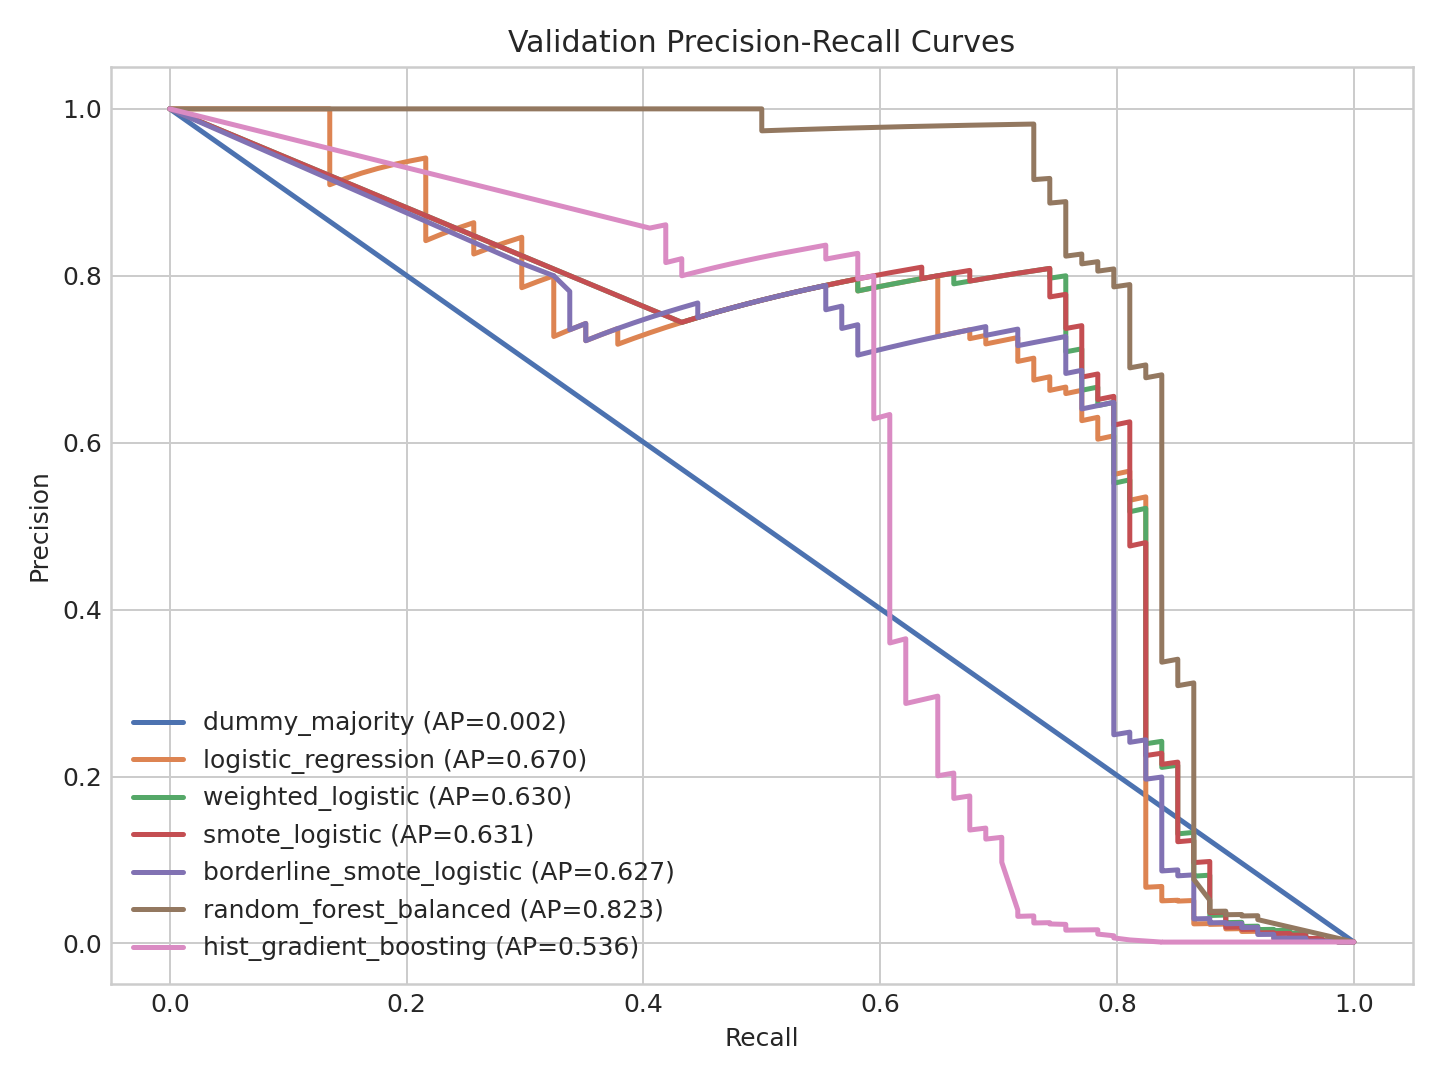

In [4]:
Image(filename=str(ARTIFACT_DIR / "precision_recall_curves.png"))

## Final Model Selection

The selected final model is the **SMOTE logistic regression**, followed by a validation-based threshold adjustment.

This choice is coherent with the project objective:

- the default threshold already gives very high recall,
- the tuned threshold recovers a much better precision/recall balance,
- the model remains interpretable and relatively lightweight.

The selected cutoff is very high (`0.9961`). This makes the final decision rule much more conservative.

In [5]:
test_view = test_metrics.copy()
test_view.columns = [
    'Accuracy', 'Precision', 'Recall', 'F1', 'Specificity', 'ROC AUC', 'PR AUC', 'TN', 'FP', 'FN', 'TP', 'Model', 'Threshold', 'Validation F2'
]
display(test_view.round(4))


,Accuracy,Precision,Recall,F1,Specificity,ROC AUC,PR AUC,TN,FP,FN,TP,Model,Threshold,Validation F2
0,0.9774,0.0637,0.8784,0.1187,0.9776,0.9675,0.7935,41692,956,9,65,smote_logistic_default_threshold,NaN,NaN
1,0.9992,0.7317,0.8108,0.7692,0.9995,0.9675,0.7935,42626,22,14,60,smote_logistic_tuned_threshold,0.9961,0.7653


## Test-Set Discussion

On the held-out test split, the tuned SMOTE logistic model reaches:

- **Precision:** about `0.732`
- **Recall:** about `0.811`
- **F1-score:** about `0.769`
- **PR AUC:** about `0.794`
- **Specificity:** about `0.9995`

This is a much more convincing outcome than the raw default-threshold version, which catches many frauds but generates too many false alarms. The tuned threshold therefore provides the best operational compromise for a professional submission.

The `PR AUC` stays the same because it depends on the ranking of predicted scores, not on one fixed threshold.

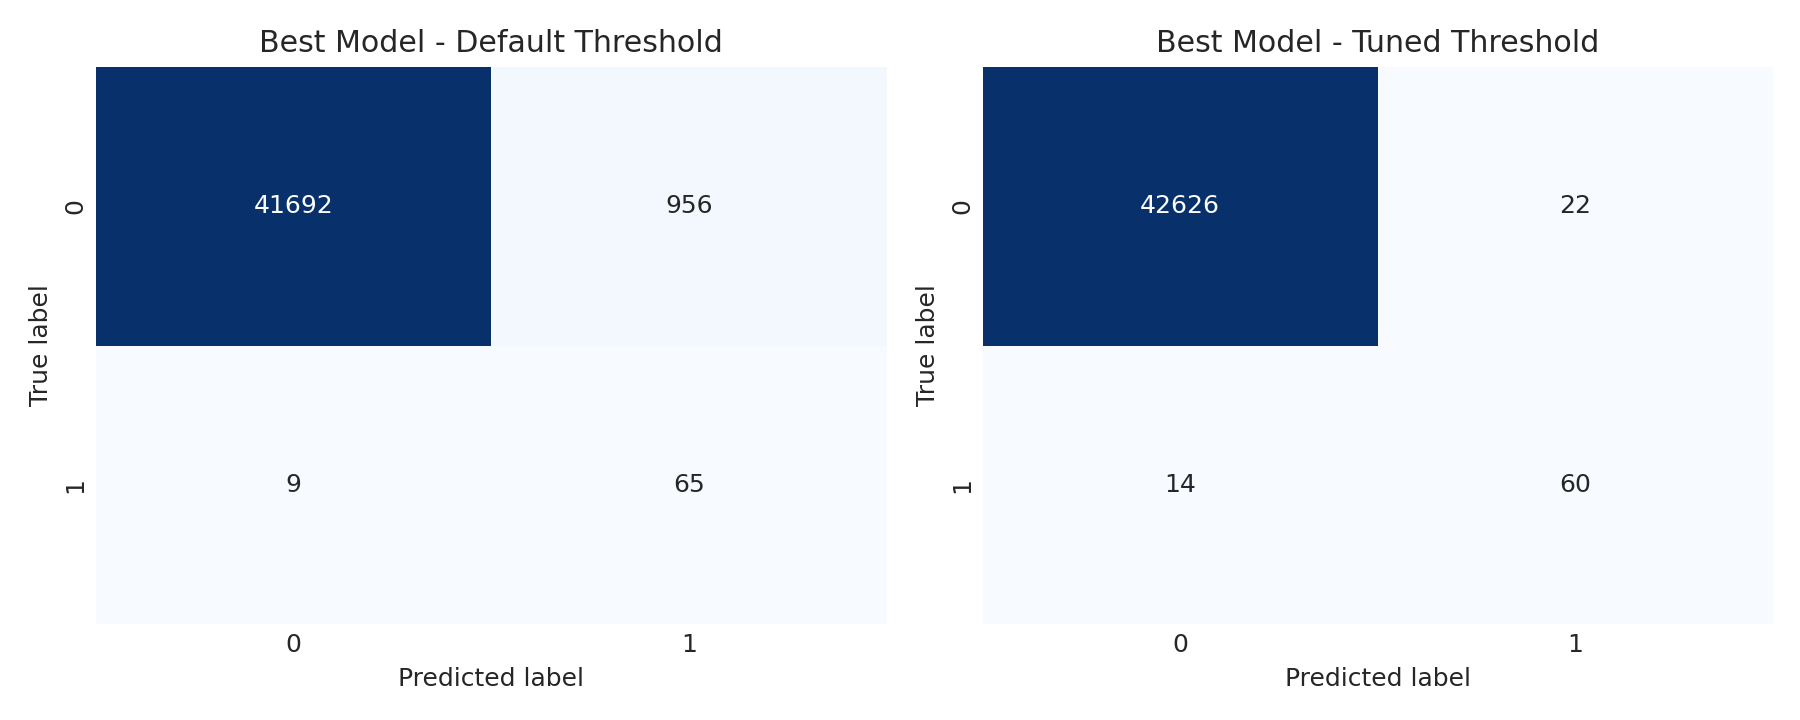

In [6]:
Image(filename=str(ARTIFACT_DIR / "confusion_matrices.png"))

## Model Interpretation

Because the final model is logistic, it remains interpretable. The coefficient plot below highlights the features with the strongest positive and negative influence on fraud probability in the transformed feature space.

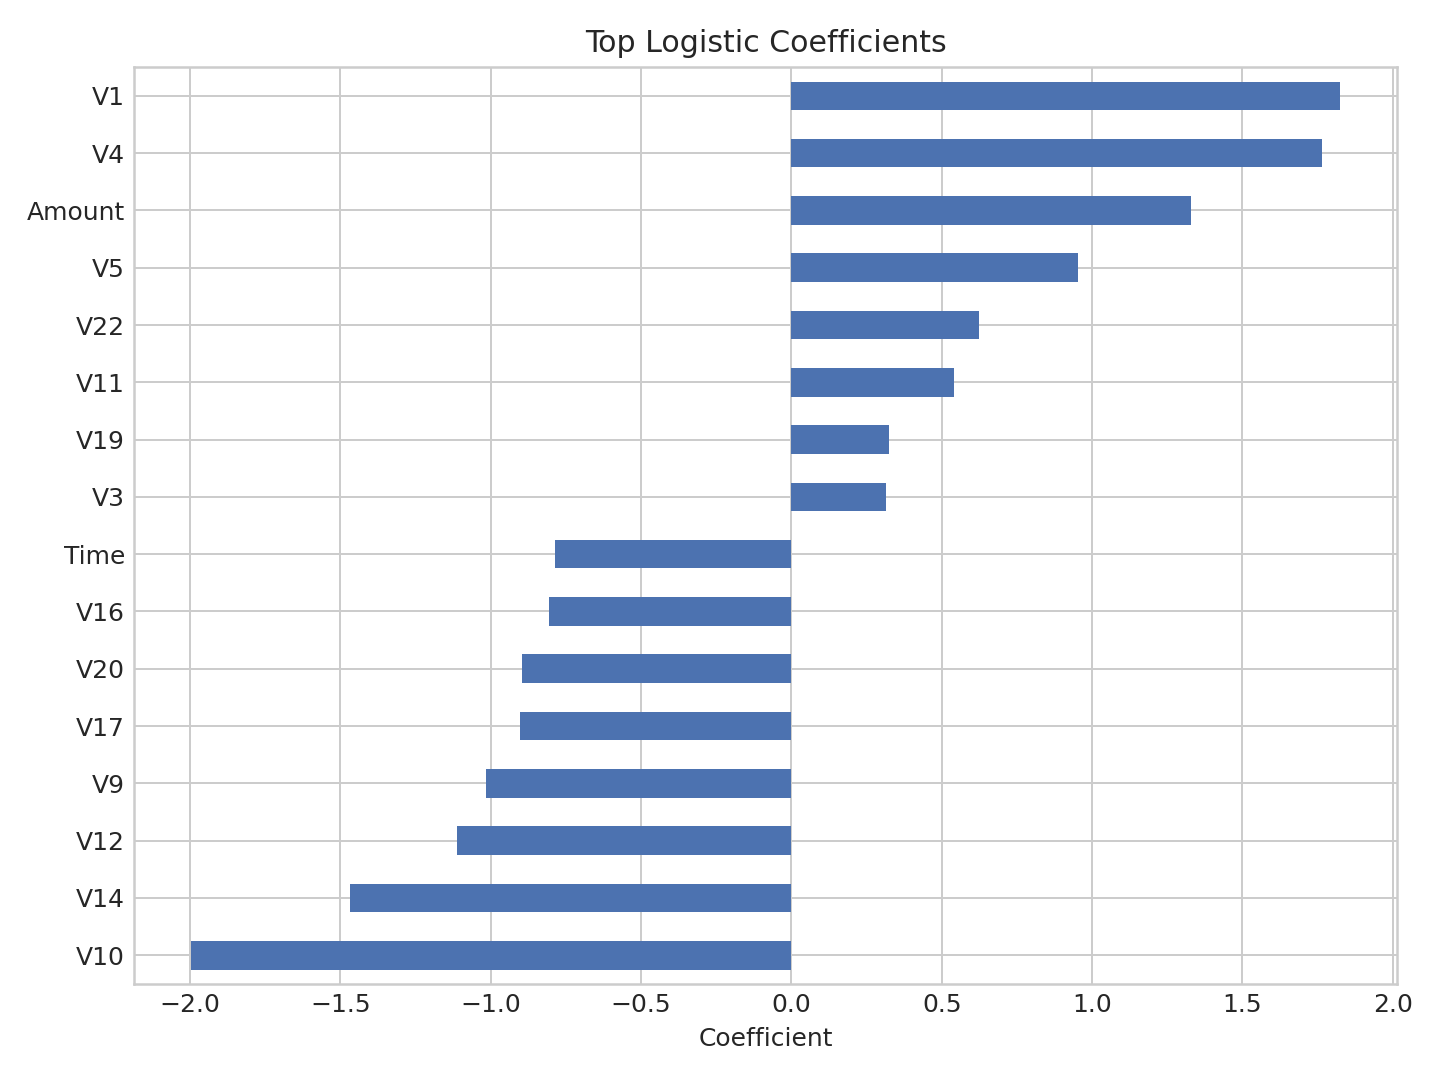

In [7]:
Image(filename=str(ARTIFACT_DIR / "logistic_coefficients.png"))

## Reproducibility

The full benchmark pipeline is stored in:

- `model_benchmark.py`

It performs the train/validation/test split, fits all candidate models, tunes the final threshold, and exports:

- `artifacts/summary.json`
- `artifacts/validation_metrics.csv`
- `artifacts/test_metrics.csv`
- the saved figures used in this notebook

As long as `data/creditcard.csv` is available locally, the project can be rerun end-to-end.

## Conclusion

The final takeaway is that **high-recall fraud detection is primarily a modelling and thresholding problem under extreme imbalance**. A naive baseline completely fails, a standard logistic model is too conservative, and the best practical solution here is a **SMOTE-enhanced logistic regression with tuned thresholding**.